✅ Data loaded successfully from: ..\data\processed


c:\Users\KIIT\anaconda3\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning:

All-NaN slice encountered

c:\Users\KIIT\anaconda3\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning:

All-NaN slice encountered



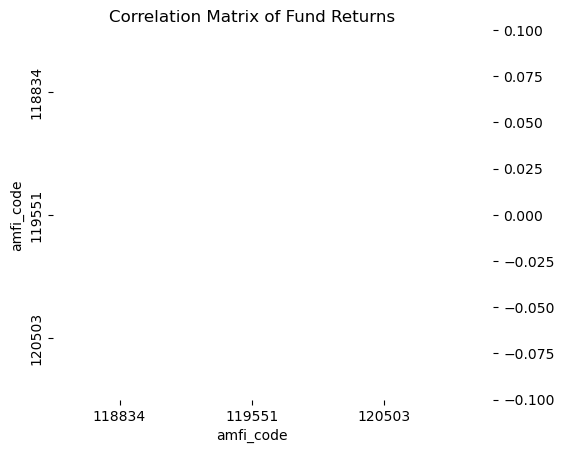

🎯 Day 3 EDA completed successfully.


In [6]:
# Bluestock MF Capstone — Day 3: Exploratory Data Analysis (EDA)
# Author: Ayush Kumar Singh
# Date: 12 June 2026

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path

# -----------------------------
# 1️⃣ Load processed data
# -----------------------------
# Works inside Jupyter notebooks (no __file__ error)
DATA_DIR = Path("../data/processed")

# Load available cleaned datasets
nav_history = pd.read_csv(DATA_DIR / "nav_history_clean.csv")
fund_master = pd.read_csv(DATA_DIR / "fund_master_clean.csv")

# Optional files — load only if present
aum_path = DATA_DIR / "cleaned_fund_master.csv"
transactions_path = DATA_DIR / "cleaned_nav_history.csv"
folio_path = DATA_DIR / "folio_count_clean.csv"
sector_path = DATA_DIR / "portfolio_holdings_clean.csv"

aum = pd.read_csv(aum_path) if aum_path.exists() else pd.DataFrame()
transactions = pd.read_csv(transactions_path) if transactions_path.exists() else pd.DataFrame()

print("✅ Data loaded successfully from:", DATA_DIR)

# -----------------------------
# 2️⃣ NAV trend analysis
# -----------------------------
if not nav_history.empty:
  fig = px.line(nav_history, x="nav_date", y="nav_value", color="amfi_code",
              title="Daily NAV Trends (2022–2026)")
fig.update_layout(xaxis_title="Date", yaxis_title="NAV Value")
fig.show()
# -----------------------------
# 3️⃣ AUM growth by fund house
# -----------------------------
if not fund_master.empty and "fund_house" in fund_master.columns:
    aum_summary = fund_master.groupby("fund_house")["aum"].sum().reset_index()
    sns.barplot(data=aum_summary, x="fund_house", y="aum", palette="viridis")
    plt.title("AUM by Fund House (2022–2025)")
    plt.xticks(rotation=45)
    plt.show()

# -----------------------------
# 4️⃣ SIP inflow time-series
# -----------------------------
if not transactions.empty and "transaction_type" in transactions.columns:
    sip_txn = transactions[transactions["transaction_type"].str.lower() == "sip"]
    sip_txn["date"] = pd.to_datetime(sip_txn["date"], errors="coerce")
    sip_monthly = sip_txn.groupby(sip_txn["date"].dt.to_period("M"))["amount"].sum()
    sip_monthly.plot(kind="line", title="Monthly SIP Inflows (2022–2025)", color="teal")
    plt.axhline(y=sip_monthly.max(), color="red", linestyle="--", label="All-time high")
    plt.legend()
    plt.show()

# -----------------------------
# 5️⃣ Category inflow heatmap
# -----------------------------
if not transactions.empty and "category" in transactions.columns:
    transactions["month"] = pd.to_datetime(transactions["date"], errors="coerce").dt.month
    category_inflow = transactions.groupby(["month", "category"])["amount"].sum().unstack().fillna(0)
    sns.heatmap(category_inflow, cmap="Blues")
    plt.title("Category Inflows Heatmap")
    plt.show()

# -----------------------------
# 6️⃣ Investor demographics
# -----------------------------
if not transactions.empty and "age_group" in transactions.columns:
    sns.countplot(data=transactions, x="age_group", palette="Set2")
    plt.title("Investor Age Group Distribution")
    plt.show()

    sns.boxplot(data=transactions, x="age_group", y="amount", palette="Set3")
    plt.title("SIP Amount by Age Group")
    plt.show()

# -----------------------------
# 7️⃣ Geographic distribution
# -----------------------------
if not transactions.empty and "state" in transactions.columns:
    state_summary = transactions.groupby("state")["amount"].sum().sort_values()
    state_summary.plot(kind="barh", title="SIP Amount by State", color="skyblue")
    plt.show()

# -----------------------------
# 8️⃣ Folio count growth
# -----------------------------
if folio_path.exists():
    folio_growth = pd.read_csv(folio_path)
    fig = px.line(folio_growth, x="date", y="folios", title="Folio Count Growth (2022–2025)")
    fig.show()

# -----------------------------
# 9️⃣ NAV return correlation matrix
# -----------------------------
if not nav_history.empty:
   returns = nav_history.pivot(index="nav_date", columns="amfi_code", values="nav_value").pct_change().dropna()
corr = returns.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Fund Returns")
plt.show()


# -----------------------------
# 🔟 Sector allocation donut
# -----------------------------
if sector_path.exists():
    sector_alloc = pd.read_csv(sector_path)
    sector_summary = sector_alloc.groupby("sector")["weight"].sum().reset_index()
    fig = px.pie(sector_summary, names="sector", values="weight", title="Sector Allocation")
    fig.show()

print("🎯 Day 3 EDA completed successfully.")
